# Telco customer churn analysis


In [3]:
import pandas as pd
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import classification_report, accuracy_score

1. Reading data

In [2]:
import pandas as pd
import sqlite3

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
raw_data = pd.read_csv(url)
print(raw_data)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1        

2. Connection to database

In [5]:
conn = sqlite3.connect('exatel_business.db')

In [6]:
raw_data.to_sql('customers', conn, if_exists='replace', index=False)
print("Database exatel_business.db has just been created")

Database exatel_business.db has just been created


3. Attributes selection:
- SeniorCitize -> different shopping habits between generations
- tenure -> long-term customers and new customers have different approach to the contracts
- MonthlyCharges -> obvious financial factor to stay/leave
- PaperlessBilling (type string 'Yes/No' so we needed to change it to 0/1) -> customers with paperless billing = 1 , no papereless billing = 0
- Churn = target

In [7]:
query = """
SELECT 
    SeniorCitizen, 
    tenure, 
    MonthlyCharges, 
    CASE WHEN PaperlessBilling = 'Yes' THEN 1 ELSE 0 END as Billing_Digital,
    CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END as target
FROM customers
WHERE TotalCharges != ' ' 
"""

df = pd.read_sql_query(query, conn)
conn.close() 

In [8]:
print(f"Rows from sql: {len(df)} ---")

Rows from sql: 7032 ---


4. Building a model (DecisionTree)

##### A. Holdout

Separating into features (X) and target (y)

In [9]:
X = df.drop('target', axis=1)
y = df['target']

Train/test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Model initialization

In [11]:
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [15]:
y_pred = clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\n - - - R E P O R T - - -")
print(classification_report(y_test, y_pred))

Accuracy: 77.68%

 - - - R E P O R T - - -
              precision    recall  f1-score   support

           0       0.81      0.91      0.86      1033
           1       0.62      0.41      0.49       374

    accuracy                           0.78      1407
   macro avg       0.72      0.66      0.67      1407
weighted avg       0.76      0.78      0.76      1407



Comment on the results:
While the accuracy suggests the model is doing quite well, we can see that the dataset is imbalanced (support). Model is struggling with the minority class 0. Recall us 0.41, it means it is missing 59% of actual class 1 cases. Precision is also much higher for class 0 (0.81) comparing to 1 class (only 0.62). Problem is sampling bias.
So the holdout method gave us an initial accuracy of 77.68%, but the low recall on Class 1 suggests the model is biased toward the majority class. To ensure this isn't just a result of a 'lucky' split, I would implement Stratified K-Fold Cross-Validation. This would give us a more reliable estimate of performance and help us determine if we need to apply techniques like SMOTE or Class Weighting to improve the detection of Class 1.

In [17]:
print("Decision Tree Logic")
tree_rules = export_text(clf, feature_names=list(X.columns))
print(tree_rules)

Decision Tree Logic
|--- tenure <= 17.50
|   |--- MonthlyCharges <= 67.50
|   |   |--- tenure <= 3.50
|   |   |   |--- class: 0
|   |   |--- tenure >  3.50
|   |   |   |--- class: 0
|   |--- MonthlyCharges >  67.50
|   |   |--- tenure <= 1.50
|   |   |   |--- class: 1
|   |   |--- tenure >  1.50
|   |   |   |--- class: 1
|--- tenure >  17.50
|   |--- MonthlyCharges <= 69.97
|   |   |--- MonthlyCharges <= 28.55
|   |   |   |--- class: 0
|   |   |--- MonthlyCharges >  28.55
|   |   |   |--- class: 0
|   |--- MonthlyCharges >  69.97
|   |   |--- tenure <= 54.50
|   |   |   |--- class: 0
|   |   |--- tenure >  54.50
|   |   |   |--- class: 0



Using stratified k-fold

In [3]:
import pandas as pd
import sqlite3
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold # Importujemy nową metodę

X = df.drop('target', axis=1)
y = df['target']


# n_splits=5 -> data into 5 folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# accuracy from each step
accuracies = []

print(f"--- validation of {skf.n_splits}-Fold ---")

fold = 1
for train_index, test_index in skf.split(X, y):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
    
    clf = DecisionTreeClassifier(max_depth=3, random_state=42)
    clf.fit(X_train_fold, y_train_fold)
    
    # prediction
    y_pred = clf.predict(X_test_fold)
    
    # output for each fold
    score = accuracy_score(y_test_fold, y_pred)
    accuracies.append(score)
    
    print(f"Fold {fold} Accuracy: {score:.2%}")
    fold += 1

# average from all folds
print(f"Mean Accuracy: {np.mean(accuracies):.2%}")
print(f"Standard deviation: {np.std(accuracies):.4f}")

# last fold's raport 
print("\nRaport for the last fold:")
print(classification_report(y_test_fold, y_pred))

--- validation of 5-Fold ---
Fold 1 Accuracy: 78.54%
Fold 2 Accuracy: 78.39%
Fold 3 Accuracy: 76.10%
Fold 4 Accuracy: 78.52%
Fold 5 Accuracy: 79.80%
Mean Accuracy: 78.27%
Standard deviation: 0.0120

Raport for the last fold:
              precision    recall  f1-score   support

           0       0.81      0.94      0.87      1032
           1       0.71      0.41      0.52       374

    accuracy                           0.80      1406
   macro avg       0.76      0.67      0.70      1406
weighted avg       0.79      0.80      0.78      1406




Average accuracy: 68.73%

Last fold's :
              precision    recall  f1-score   support

           0       0.91      0.58      0.71      1032
           1       0.42      0.84      0.56       374

    accuracy                           0.65      1406
   macro avg       0.66      0.71      0.63      1406
weighted avg       0.78      0.65      0.67      1406



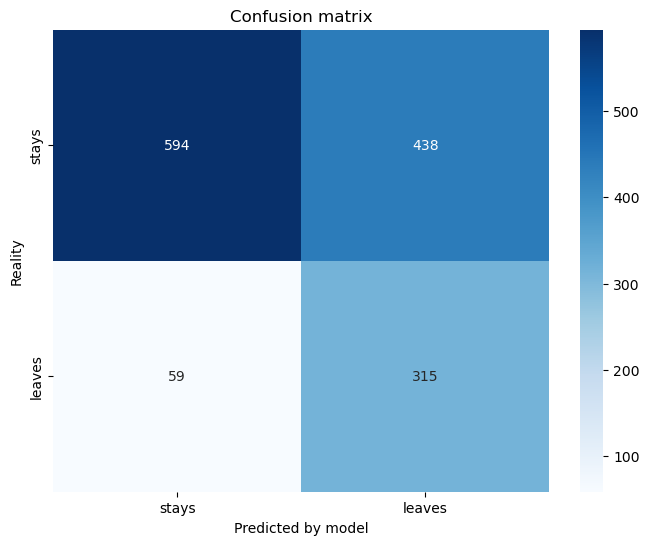

In [4]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
raw_data = pd.read_csv(url)

conn = sqlite3.connect('exatel_business.db')
raw_data.to_sql('customers', conn, if_exists='replace', index=False)


query = """
SELECT 
    SeniorCitizen, 
    tenure, 
    MonthlyCharges, 
    CASE WHEN PaperlessBilling = 'Yes' THEN 1 ELSE 0 END as Billing_Digital,
    CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END as target
FROM customers
WHERE TotalCharges != ' ' 
"""

df = pd.read_sql_query(query, conn)
conn.close()

X = df.drop('target', axis=1)
y = df['target']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    # class_weight = 'balanced'
    clf = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

print(f"\nAverage accuracy: {np.mean(accuracies):.2%}")
print("\nLast fold's :")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['stays', 'leaves'], 
            yticklabels=['stays', 'leaves'])
plt.xlabel('Predicted by model')
plt.ylabel('Reality')
plt.title('Confusion matrix')
plt.show()



- Initial Result: High accuracy (78%), but a very low Recall (41%). The model was missing 59% of the customers who actually left.

- The Solution: Implemented Stratified K-Fold Cross-Validation to ensure every training slice was representative, and  applied class_weight='balanced' to the Decision Tree. This forced the model to prioritize the minority "Churn" class.

#### Final verdict
- True Positives (315): These are customers the model correctly identified as "at risk." 

- False Positives (438): These are customers which want to stay but the model flagged as risky. While this might lead to some unnecessary marketing outreach, the cost of a phone call would be negligible compared to the cost of losing a customer.

- Finally recall (0.84): We are now capturing 84% of all potential churners.

- I transitioned from a holdout to stratified k-fold validation to ensure the model's stability. Given the imbalanced nature of churn data, stratification guaranteed that the minority class was represented in every fold, while the k-fold approach provided a more robust estimate of the model's true performance by testing it on multiple data segments.